# Modelos de Previsão de Retorno — Abordagem Tabular

Este notebook implementa e compara modelos de previsão do retorno futuro de 21 pregões
para os ativos do S&P 500, usando a abordagem de **regressão tabular cross-sectional**.

Em vez de tratar cada ativo como uma série temporal independente, todas as observações
de todos os ativos são combinadas em um único conjunto de dados tabulares. Isso permite:

- Aproveitar os ~1 milhão de registros gerados no notebook anterior;
- O modelo aprender padrões generalizáveis entre ativos;
- Capturar informação cross-sectional: qual ativo performa melhor *em relação aos demais* em cada data.

**Modelos avaliados:**

1. **Regressão Linear Ridge** — baseline simples e interpretável;
2. **Random Forest** — ensemble de árvores de decisão com bagging;
3. **LightGBM** — gradient boosting sobre árvores de decisão, padrão em aplicações quantitativas.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## Configuração do Projeto

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

FEATURES_FILE    = "sp500_features.csv"
PREDICTIONS_FILE = "model_predictions_21d.csv"
METRICS_FILE     = "model_metrics.csv"

# Divisão temporal
TRAIN_END = "2022-12-31"
VAL_END   = "2023-12-31"

FEATURE_COLS = [
    "ret_1d",
    "ret_5d",
    "ret_21d",
    "vol_21d",
    "vol_63d",
    "sma_20_ratio",
    "sma_50_ratio",
    "volume_ratio_21d",
    "drawdown_63d",
    "close_position_21d",
    "high_low_range",
    "high_low_range_21d",
]

TARGET_COL     = "target_21d"
TARGET_LOG_COL = "target_21d_log"

RANDOM_STATE = 42

## Leitura e Preparação dos Dados

Os dados foram gerados no notebook `02_feature_engineering.ipynb`.

O target é transformado para log-retorno antes do treinamento para comprimir valores
extremos sem remover eventos reais de mercado. As previsões são convertidas de volta
ao espaço original para avaliação e interpretação.

In [3]:
df = pd.read_csv(
    PROCESSED_DATA_DIR / FEATURES_FILE,
    parse_dates=["date"]
)

df[TARGET_LOG_COL] = np.log(1 + df[TARGET_COL])

print(f"Total de linhas: {len(df):,}")
print(f"Ativos:          {df['ticker'].nunique()}")
print(f"Período:         {df['date'].min().date()} -> {df['date'].max().date()}")
df.head()

Total de linhas: 1,002,184
Ativos:          502
Período:         2018-04-04 -> 2026-05-13


,date,ticker,open,high,low,close,volume,ret_1d,ret_5d,ret_21d,...,sma_50_ratio,volume_ratio_21d,drawdown_63d,close_position_21d,high_low_range,high_low_range_21d,target_21d,target_21d_log,company,sector
0,2018-04-04,A,60.415396,61.828070,59.944504,61.639709,5084100.0,0.000458,-0.020954,-0.028926,...,0.942796,2.021071,-0.123282,0.155921,0.030558,0.021859,0.013598,0.013507,Agilent Technologies,Health Care
1,2018-04-05,A,61.988191,62.449663,61.686821,61.856342,2120200.0,0.003515,-0.008635,-0.033525,...,0.948184,0.856200,-0.120200,0.191084,0.012332,0.021768,0.020097,0.019898,Agilent Technologies,Health Care
2,2018-04-06,A,61.225337,61.743314,59.690229,59.944511,3578600.0,-0.030908,-0.046456,-0.084762,...,0.921477,1.432671,-0.147393,0.000000,0.034250,0.021650,0.058759,0.057097,Agilent Technologies,Health Care
3,2018-04-09,A,61.140566,62.393140,60.349472,61.394852,2639800.0,0.024195,0.011795,-0.064631,...,0.946102,1.053086,-0.126764,0.210336,0.033287,0.022499,0.033441,0.032894,Agilent Technologies,Health Care
4,2018-04-10,A,62.289576,62.901737,62.063550,62.760468,1872800.0,0.022243,0.018649,-0.061032,...,0.969401,0.749793,-0.107341,0.433179,0.013355,0.022130,0.022359,0.022112,Agilent Technologies,Health Care


## Split Temporal

A divisão respeita estritamente a ordem cronológica para evitar vazamento de informação futura.
Dados do futuro não podem influenciar o treino — o modelo só enxerga o que estaria disponível
no momento da decisão.

| Conjunto    | Período       | Uso                                      |
|-------------|---------------|------------------------------------------|
| Treino      | 2018 – 2022   | Ajuste dos parâmetros do modelo          |
| Validação   | 2023          | Early stopping e ajuste de hiperparâmetros |
| Teste       | 2024 – 2026   | Avaliação final (dados nunca vistos)     |

In [4]:
train_df = df[df["date"] <= TRAIN_END].copy()
val_df   = df[(df["date"] > TRAIN_END) & (df["date"] <= VAL_END)].copy()
test_df  = df[df["date"] > VAL_END].copy()

print(f"Treino:    {train_df['date'].min().date()} -> {train_df['date'].max().date()}  ({len(train_df):,} linhas)")
print(f"Validação: {val_df['date'].min().date()} -> {val_df['date'].max().date()}  ({len(val_df):,} linhas)")
print(f"Teste:     {test_df['date'].min().date()} -> {test_df['date'].max().date()}  ({len(test_df):,} linhas)")

Treino:    2018-04-04 -> 2022-12-30  (581,619 linhas)
Validação: 2023-01-03 -> 2023-12-29  (124,051 linhas)
Teste:     2024-01-02 -> 2026-05-13  (296,514 linhas)


## Preparação das Matrizes de Entrada

O treino e a validação usam o log-retorno como target para estabilidade numérica.

A avaliação final no conjunto de teste é feita no retorno original (`target_21d`)
para manter a interpretabilidade dos resultados.

In [5]:
X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET_LOG_COL].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df[TARGET_LOG_COL].values

X_test = test_df[FEATURE_COLS].values

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (581619, 12)
X_val:   (124051, 12)
X_test:  (296514, 12)


## Modelo 1 — Regressão Linear Ridge (Baseline)

A regressão linear com regularização Ridge serve como baseline: simples, rápida e
totalmente interpretável pelos coeficientes.

As features são padronizadas (média 0, desvio padrão 1) para estabilidade numérica.
As previsões em log-retorno são convertidas de volta ao espaço original com `exp(y) - 1`.

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

linear_model = Ridge(alpha=1.0)
linear_model.fit(X_train_sc, y_train)

test_df["pred_linear"] = np.exp(linear_model.predict(X_test_sc)) - 1

print("Regressão Linear treinada.")

Regressão Linear treinada.


## Modelo 2 — Random Forest

O Random Forest é um ensemble de árvores de decisão treinadas com bagging:
cada árvore é ajustada em uma amostra aleatória dos dados e usa um subconjunto
aleatório de features em cada divisão. A previsão final é a média de todas as árvores.

Vantagens para este problema:

- Captura relações não-lineares sem necessidade de padronização;
- Robusto a overfitting pelo mecanismo de bagging;
- Paralelizável — treina cada árvore de forma independente.

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

test_df["pred_rf"] = np.exp(rf.predict(X_test)) - 1

print("Random Forest treinado.")

Random Forest treinado.


## Modelo 3 — LightGBM

O LightGBM é um modelo de gradient boosting baseado em árvores de decisão.
Vantagens para este problema:

- Captura relações não-lineares entre features e retorno;
- Escala bem com ~1 milhão de observações;
- Não requer padronização das features;
- Fornece importância das features para interpretação.

O early stopping monitora a perda no conjunto de validação e interrompe o treino
quando ela para de melhorar, prevenindo overfitting.

In [8]:
lgbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=200)
    ]
)

test_df["pred_lgbm"] = np.exp(lgbm.predict(X_test)) - 1

print(f"\nMelhor iteração: {lgbm.best_iteration_}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[66]	valid_0's l2: 0.00753126

Melhor iteração: 66


c:\Users\Daniel\miniconda3\envs\financial_market\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Avaliação dos Modelos

Métricas utilizadas:

- **MAE / RMSE** — erro médio absoluto e quadrático no espaço de retorno;
- **R²** — proporção da variância explicada (1 = perfeito, 0 = igual à média, negativo = pior que a média);
- **IC (Information Coefficient)** — correlação de Spearman média entre retorno previsto e real, calculada por data;
- **ICIR** — IC dividido pelo seu desvio padrão, mede a *consistência* do modelo ao longo do tempo.

IC e ICIR são as métricas padrão em finanças quantitativas para modelos de ranking de ativos.
Um IC > 0.05 já é considerado relevante na indústria.

In [9]:
def compute_metrics(df, pred_col, actual_col=TARGET_COL, date_col="date"):
    y_true = df[actual_col]
    y_pred = df[pred_col]

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    daily_ic = (
        df[[date_col, pred_col, actual_col]]
        .groupby(date_col)
        .apply(lambda g: g[pred_col].corr(g[actual_col], method="spearman"))
        .dropna()
    )
    ic   = daily_ic.mean()
    icir = ic / daily_ic.std()

    return {
        "MAE":  round(mae, 6),
        "RMSE": round(rmse, 6),
        "R2":   round(r2, 4),
        "IC":   round(ic, 4),
        "ICIR": round(icir, 4)
    }

In [10]:
metrics = []

for model_name, pred_col in [
    ("Linear Regression", "pred_linear"),
    ("Random Forest",     "pred_rf"),
    ("LightGBM",          "pred_lgbm")
]:
    m = compute_metrics(test_df, pred_col)
    m["model"] = model_name
    metrics.append(m)

metrics_df = (
    pd.DataFrame(metrics)[["model", "MAE", "RMSE", "R2", "IC", "ICIR"]]
    .sort_values("IC", ascending=False)
    .reset_index(drop=True)
)

metrics_df

,model,MAE,RMSE,R2,IC,ICIR
0,Linear Regression,0.069682,0.099244,0.0049,0.0382,0.1987
1,LightGBM,0.069428,0.099454,0.0006,0.0352,0.2100
2,Random Forest,0.070074,0.099883,-0.0080,0.0279,0.1774


## Importância das Features — LightGBM

A importância mede o ganho médio de cada feature nas divisões das árvores.
Features com alta importância têm maior influência na previsão do retorno.

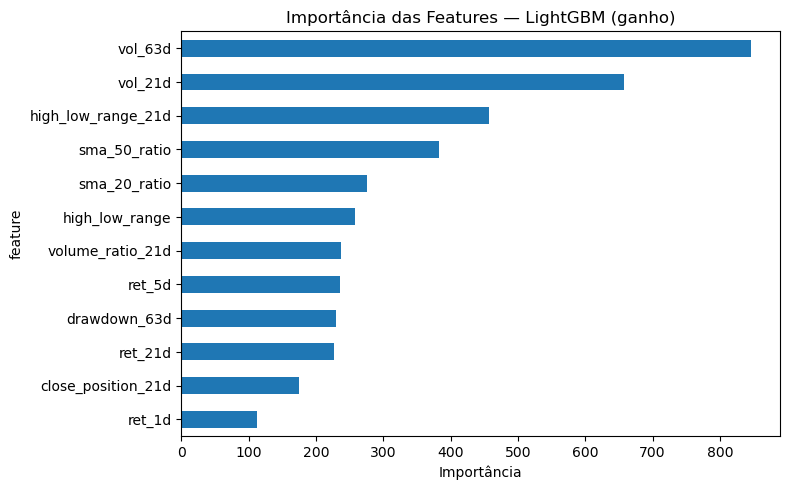

In [11]:
importance = (
    pd.DataFrame({
        "feature":    FEATURE_COLS,
        "importance": lgbm.feature_importances_
    })
    .sort_values("importance", ascending=True)
)

importance.plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 5),
    legend=False,
    title="Importância das Features — LightGBM (ganho)"
)
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

## Salvamento das Previsões e Métricas

As previsões do conjunto de teste e as métricas são salvas em `data/processed`
para uso na etapa de recomendação de carteiras por perfil de usuário.

In [12]:
predictions_df = test_df[
    ["date", "ticker", TARGET_COL, "pred_linear", "pred_rf", "pred_lgbm"]
].rename(columns={
    TARGET_COL:    "actual_return_21d",
    "pred_linear": "pred_linear_return_21d",
    "pred_rf":     "pred_rf_return_21d",
    "pred_lgbm":   "pred_lgbm_return_21d"
})

predictions_df.to_csv(PROCESSED_DATA_DIR / PREDICTIONS_FILE, index=False)
metrics_df.to_csv(PROCESSED_DATA_DIR / METRICS_FILE, index=False)
importance.to_csv(PROCESSED_DATA_DIR / "feature_importance_lgbm.csv", index=False)
joblib.dump(linear_model, PROCESSED_DATA_DIR / "linear_model.pkl")
joblib.dump(scaler, PROCESSED_DATA_DIR / "scaler.pkl")

print("Arquivos salvos com sucesso.")
print(f"Previsoes:       {PREDICTIONS_FILE} ({len(predictions_df):,} linhas)")
print(f"Metricas:        {METRICS_FILE}")
print(f"Modelo Ridge:    linear_model.pkl")
print(f"Scaler:          scaler.pkl")

Arquivos salvos com sucesso.
Previsoes:       model_predictions_21d.csv (296,514 linhas)
Metricas:        model_metrics.csv
Modelo Ridge:    linear_model.pkl
Scaler:          scaler.pkl


## Próximos Passos

Com as previsões de retorno disponíveis, o próximo notebook irá:

- Definir perfis de usuário (conservador, moderado, arrojado);
- Construir portfólios personalizados combinando retorno previsto e risco (volatilidade histórica);
- Avaliar o desempenho das carteiras recomendadas no período de teste.